     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Saving WhatsApp Image 2025-02-06 at 14.00.10_416bd6a3.jpg to WhatsApp Image 2025-02-06 at 14.00.10_416bd6a3.jpg


Saving WhatsApp Image 2025-09-19 at 19.37.29_144708b1.jpg to WhatsApp Image 2025-09-19 at 19.37.29_144708b1.jpg


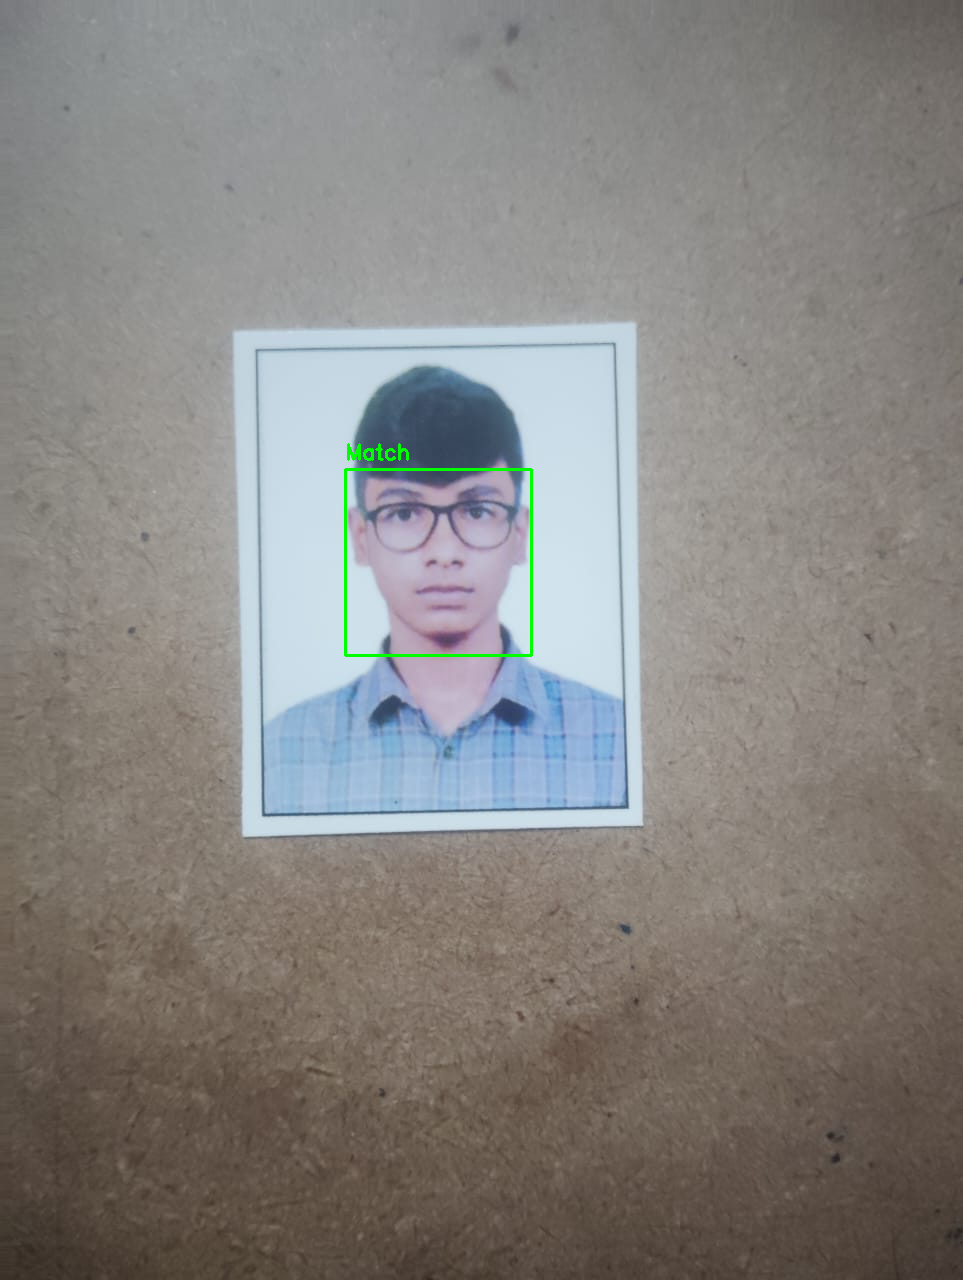

In [ ]:
!pip install face_recognition -q
import face_recognition, cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# Upload reference and test images
ref = files.upload()
ref_enc = face_recognition.face_encodings(face_recognition.load_image_file(list(ref.keys())[0]))[0]

test = files.upload()
test_path = list(test.keys())[0]
img = face_recognition.load_image_file(test_path)
locations = face_recognition.face_locations(img)
encodings = face_recognition.face_encodings(img, locations)

# Compare and draw results
output = cv2.imread(test_path)
for (top, right, bottom, left), enc in zip(locations, encodings):
    match = face_recognition.compare_faces([ref_enc], enc)[0]
    color = (0,255,0) if match else (0,0,255)
    cv2.rectangle(output, (left, top), (right, bottom), color, 2)
    cv2.putText(output, "Match" if match else "No Match", (left, top-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

cv2_imshow(output)

Upload Reference Image


Saving WhatsApp Image 2025-02-06 at 14.00.10_416bd6a3.jpg to WhatsApp Image 2025-02-06 at 14.00.10_416bd6a3 (2).jpg
Upload Test Image


Saving WhatsApp Image 2025-09-19 at 19.37.29_144708b1.jpg to WhatsApp Image 2025-09-19 at 19.37.29_144708b1 (2).jpg
Result: MATCH
Face Distance: 0.186


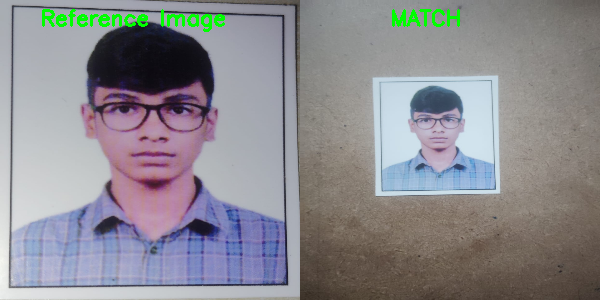

In [ ]:
!pip install face_recognition -q

import face_recognition
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload Reference Image
print("Upload Reference Image")
ref = files.upload()
ref_path = list(ref.keys())[0]

# Upload Test Image
print("Upload Test Image")
test = files.upload()
test_path = list(test.keys())[0]

# Load images
ref_img = face_recognition.load_image_file(ref_path)
test_img = face_recognition.load_image_file(test_path)

# Face encodings
ref_enc = face_recognition.face_encodings(ref_img)
test_enc = face_recognition.face_encodings(test_img)

if len(ref_enc) == 0 or len(test_enc) == 0:
    print("Face not detected in one of the images.")
else:
    # Compare faces
    match = face_recognition.compare_faces([ref_enc[0]], test_enc[0])[0]
    distance = face_recognition.face_distance([ref_enc[0]], test_enc[0])[0]

    result = "MATCH" if match else "NO MATCH"
    print("Result:", result)
    print("Face Distance:", round(distance, 3))

    # Convert RGB to BGR
    ref_display = cv2.cvtColor(ref_img, cv2.COLOR_RGB2BGR)
    test_display = cv2.cvtColor(test_img, cv2.COLOR_RGB2BGR)

    # Resize to same height
    h = 300
    ref_display = cv2.resize(ref_display, (300, h))
    test_display = cv2.resize(test_display, (300, h))

    # Put labels
    cv2.putText(ref_display, "Reference Image", (40,25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,255,0), 2)

    cv2.putText(test_display, result, (90,25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (0,255,0) if match else (0,0,255), 2)

    # Combine images side by side
    combined = np.hstack((ref_display, test_display))

    # Show combined image
    cv2_imshow(combined)